Epoca 50/250 | Loss Media Batch: -0.6076
Epoca 100/250 | Loss Media Batch: -1.5982
Epoca 150/250 | Loss Media Batch: -2.0584
Epoca 200/250 | Loss Media Batch: -2.3557
Epoca 250/250 | Loss Media Batch: -2.5727


/var/folders/nd/ckd2p671409_45_1_kmhw0bh0000gn/T/ipykernel_2701/61745381.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', k_concepts)


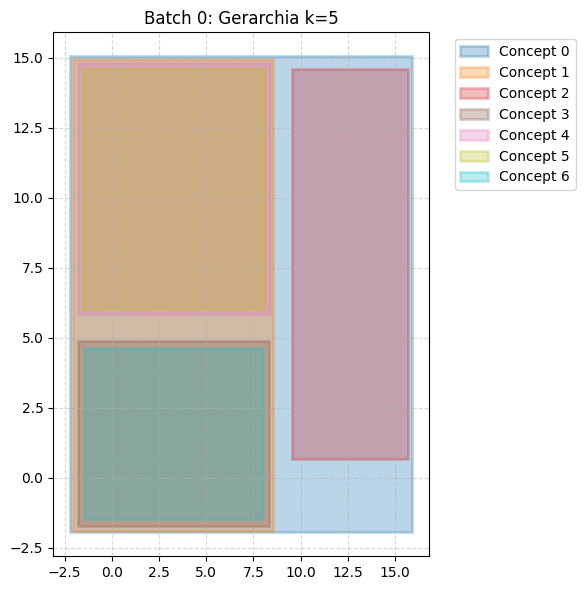

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import numpy as np
from box_embeddings.parameterizations import MinDeltaBoxTensor
from box_embeddings.modules.intersection import GumbelIntersection
from box_embeddings.modules.volume import SoftVolume

# --- 1. SETUP GENERALIZZATO ---
k = 7  # Numero arbitrario di concetti
num_dims = 2
feature_dim = 64
batch_size = 4

torch.manual_seed(42)
features = torch.randn(batch_size, feature_dim)

# Creiamo dinamicamente k proiettori separati
projectors = nn.ModuleList([
    nn.Linear(in_features=feature_dim, out_features=2 * num_dims) for _ in range(k)
])

optimizer = torch.optim.Adam(projectors.parameters(), lr=0.01)

gumbel_intersection = GumbelIntersection(intersection_temperature=0.1)
soft_volume = SoftVolume(volume_temperature=0.5)

# --- 2. GROUND TRUTH (Albero Gerarchico per k=5) ---
supervisions = [
    (0, 1, 1.0),  # C0 contiene C1
    (0, 2, 1.0),  # C0 contiene C2
    (1, 2, 0.0),  # C1 e C2 disgiunti
    (2, 1, 0.0),  # REGOLA SIMMETRICA: C2 disgiunto da C1
    (1, 3, 1.0),  # C1 contiene C3
    (1, 4, 1.0),  # C1 contiene C4
    (3, 4, 0.0),  # C3 e C4 disgiunti
    (4, 3, 0.0),  # Simmetria necessaria se no la rete bara includendo C3 in C4 e aumentando il più possibile il volume
    (4, 5, 1.0),  # C4 contiente C5
    (3, 6, 1.0),  # C5 contiene C6
]

# --- 3. FUNZIONE DI VISUALIZZAZIONE DINAMICA ---
def plot_boxes_k(boxes_list, batch_idx, k_concepts, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Generiamo dinamicamente k colori da una colormap
    colormap = cm.get_cmap('tab10', k_concepts)
    
    for i in range(k_concepts):
        # Estraiamo le coordinate per l'elemento del batch
        z_coords = boxes_list[i].z[batch_idx].detach().numpy()
        Z_coords = boxes_list[i].Z[batch_idx].detach().numpy()
        
        width = Z_coords[0] - z_coords[0]
        height = Z_coords[1] - z_coords[1]
        
        color = colormap(i)
        rect = patches.Rectangle((z_coords[0], z_coords[1]), width, height, 
                                 linewidth=2, edgecolor=color, facecolor=color, 
                                 alpha=0.3, label=f'Concept {i}')
        ax.add_patch(rect)
        
    ax.autoscale_view()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- 4. LOOP DI ADDESTRAMENTO GENERALIZZATO ---
epochs = 250 

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Proiezioni dinamiche per k layer
    # Usiamo una list comprehension per ottenere i tensori da tutti i layer
    boxes = []
    for i in range(k):
        theta_i = projectors[i](features) # Shape: (batch_size, 4)
        box_i = MinDeltaBoxTensor(theta_i.view(batch_size, 2, num_dims))
        boxes.append(box_i)
    
    total_loss = 0.0
    
    # 2. Calcoliamo la loss iterando sulla ground truth
    for target_id, source_id, target_prob in supervisions:
        b_target = boxes[target_id]
        b_source = boxes[source_id]
        
        int_box = gumbel_intersection(b_target, b_source)
        
        log_vol_int = soft_volume(int_box)
        log_vol_source = soft_volume(b_source)
        
        pred_prob = torch.exp(log_vol_int - log_vol_source)
        pred_prob = torch.clamp(pred_prob, 1e-6, 1.0 - 1e-6)
        
        target_tensor = torch.full((batch_size,), target_prob, dtype=torch.float32)
        
        loss = F.binary_cross_entropy(pred_prob, target_tensor)
        total_loss += loss
    
    # 3. Contromisura Anti-Collasso automatica
    # Applichiamo un piccolo incentivo al volume per tutti i concetti (eccetto la radice 0 se vogliamo)
    vol_loss = 0.0
    for i in range(1, k):
        vol_loss -= 0.1 * soft_volume(boxes[i]).mean()

    final_loss = total_loss + vol_loss
    final_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoca {epoch + 1}/{epochs} | Loss Media Batch: {final_loss.item():.4f}")

# Visualizziamo i risultati a fine addestramento
with torch.no_grad():
    final_boxes = []
    for i in range(k):
        t = projectors[i](features).view(batch_size, 2, num_dims)
        final_boxes.append(MinDeltaBoxTensor(t))

plot_boxes_k(final_boxes, batch_idx=0, k_concepts=k, title="Batch 0: Gerarchia k=5")

/var/folders/nd/ckd2p671409_45_1_kmhw0bh0000gn/T/ipykernel_2701/61745381.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', k_concepts)


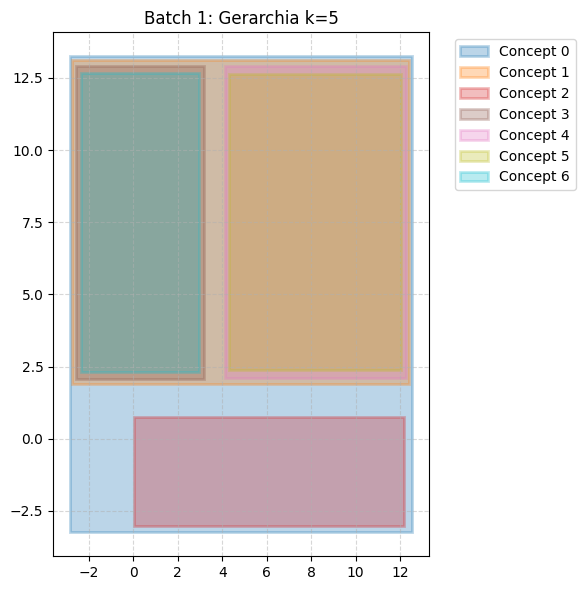

In [4]:
plot_boxes_k(final_boxes, batch_idx=1, k_concepts=k, title="Batch 1: Gerarchia k=5")